In [78]:
%pip install -r "requirements.txt"

ERROR: Could not open requirements file: [Errno 2] File o directory non esistente: 'requirements.txt'
Note: you may need to restart the kernel to use updated packages.


In [79]:
import sys
import os

path = os.path.expanduser('~/Documenti/Tesi-Magistrale')
os.chdir(path)
# Aggiunge la directory corrente al PATH per trovare 'src'
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

print(f"Directory attuale: {os.getcwd()}")

Directory attuale: /home/andy/Documenti/Tesi-Magistrale


In [80]:
import pandas as pd
from pathlib import Path
import missingno as msno
import matplotlib.pyplot as plt

In [81]:
metadati = pd.read_csv("data/mimic-cxr-2.0.0-metadata.csv")
metadati = metadati[metadati['ViewPosition'] != 'LATERAL']
metadati

,dicom_id,subject_id,study_id,PerformedProcedureStepDescription,ViewPosition,Rows,Columns,StudyDate,StudyTime,ProcedureCodeSequence_CodeMeaning,ViewCodeSequence_CodeMeaning,PatientOrientationCodeSequence_CodeMeaning
0,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,10000032,50414267,CHEST (PA AND LAT),PA,3056,2544,21800506,213014.531,CHEST (PA AND LAT),postero-anterior,Erect
2,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,10000032,53189527,CHEST (PA AND LAT),PA,3056,2544,21800626,165500.312,CHEST (PA AND LAT),postero-anterior,Erect
4,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714,10000032,53911762,CHEST (PORTABLE AP),AP,2705,2539,21800723,80556.875,CHEST (PORTABLE AP),antero-posterior,NaN
5,fffabebf-74fd3a1f-673b6b41-96ec0ac9-2ab69818,10000032,53911762,CHEST (PORTABLE AP),AP,2906,2258,21800723,80556.875,CHEST (PORTABLE AP),antero-posterior,Erect
6,ea030e7a-2e3b1346-bc518786-7a8fd698-f673b44c,10000032,56699142,CHEST (PORTABLE AP),AP,3056,2544,21800805,234424.765,CHEST (PORTABLE AP),antero-posterior,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
377104,3fcd0406-9b111603-feae7033-96632b3a-111333e5,19999733,57132437,CHEST (PA AND LAT),PA,3056,2544,21520708,224550.171,CHEST (PA AND LAT),postero-anterior,Erect
377105,428e2c18-5721d8f3-35a05001-36f3d080-9053b83c,19999733,57132437,CHEST (PA AND LAT),PA,3056,2544,21520708,224550.171,CHEST (PA AND LAT),postero-anterior,Erect
377107,58766883-376a15ce-3b323a28-6af950a0-16b793bd,19999987,55368167,CHEST (PORTABLE AP),AP,2544,3056,21451104,51448.218,CHEST (PORTABLE AP),antero-posterior,Erect
377108,7ba273af-3d290f8d-e28d0ab4-484b7a86-7fc12b08,19999987,58621812,CHEST (PORTABLE AP),AP,3056,2544,21451102,202809.234,CHEST (PORTABLE AP),antero-posterior,Erect


In [82]:
lista_immagini = []
ricerca = Path(os.path.join("data", "MIMIC_SUPER_RES_24K"))
for file_path in ricerca.rglob('*.jpg'):
    dicom_id = file_path.stem
    lista_immagini.append({'dicom_id': dicom_id, 'path_immagine': str(file_path)})
immagini = pd.DataFrame(lista_immagini)
immagini['path_immagine'] = immagini['path_immagine'].str.replace(str(path+"/"), "data/", regex=False) # pulisci il path
immagini['dicom_id'] = immagini['dicom_id'].astype(str)
print(f"{len(immagini)} immagini")
immagini.head()

24000 immagini


,dicom_id,path_immagine
0,62456122-1887ff8c-ef1cba37-270fe1ac-c88ef7fc,data/MIMIC_SUPER_RES_24K/62456122-1887ff8c-ef1...
1,152c3005-d0c7bf7a-4c0f7935-e82aef6e-bed96e2e,data/MIMIC_SUPER_RES_24K/152c3005-d0c7bf7a-4c0...
2,c4a20cd5-94e7d182-0bbca8a9-797c8bf5-7e12e050,data/MIMIC_SUPER_RES_24K/c4a20cd5-94e7d182-0bb...
3,064741c9-95255009-ae0c53ee-ccb54164-21b77bbb,data/MIMIC_SUPER_RES_24K/064741c9-95255009-ae0...
4,2150ba84-0f87ae6f-a7132d8e-8b02fb6c-99745702,data/MIMIC_SUPER_RES_24K/2150ba84-0f87ae6f-a71...


In [83]:
dataset = immagini.merge(metadati, how='left', on='dicom_id')
dataset

,dicom_id,path_immagine,subject_id,study_id,PerformedProcedureStepDescription,ViewPosition,Rows,Columns,StudyDate,StudyTime,ProcedureCodeSequence_CodeMeaning,ViewCodeSequence_CodeMeaning,PatientOrientationCodeSequence_CodeMeaning
0,62456122-1887ff8c-ef1cba37-270fe1ac-c88ef7fc,data/MIMIC_SUPER_RES_24K/62456122-1887ff8c-ef1...,16994397,52464683,CHEST (PORTABLE AP),AP,2539,3050,21130701,170824.250,CHEST (PORTABLE AP),antero-posterior,Erect
1,152c3005-d0c7bf7a-4c0f7935-e82aef6e-bed96e2e,data/MIMIC_SUPER_RES_24K/152c3005-d0c7bf7a-4c0...,14716808,57354809,NaN,PA,2022,1736,21990614,134835.000,CHEST (PA AND LAT),postero-anterior,Erect
2,c4a20cd5-94e7d182-0bbca8a9-797c8bf5-7e12e050,data/MIMIC_SUPER_RES_24K/c4a20cd5-94e7d182-0bb...,14073672,51550911,CHEST (PA AND LAT),PA,2952,2500,21701024,155525.203,CHEST (PA AND LAT),postero-anterior,Erect
3,064741c9-95255009-ae0c53ee-ccb54164-21b77bbb,data/MIMIC_SUPER_RES_24K/064741c9-95255009-ae0...,16012667,50941182,CHEST (PORTABLE AP),AP,3035,2539,21320611,33907.343,CHEST (PORTABLE AP),antero-posterior,Erect
4,2150ba84-0f87ae6f-a7132d8e-8b02fb6c-99745702,data/MIMIC_SUPER_RES_24K/2150ba84-0f87ae6f-a71...,17686783,50124464,CHEST (PORTABLE AP),AP,3056,2544,21720209,51446.375,CHEST (PORTABLE AP),antero-posterior,Erect
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23995,ea8df8e0-364885ff-4faf78fd-cab5c93b-a88c32b4,data/MIMIC_SUPER_RES_24K/ea8df8e0-364885ff-4fa...,16117323,56937638,CHEST (PA AND LAT),AP,2544,3056,21911114,223409.140,CHEST (PA AND LAT),antero-posterior,Erect
23996,eb76f199-dc94ddad-e7095f97-8671879f-4606de18,data/MIMIC_SUPER_RES_24K/eb76f199-dc94ddad-e70...,14522445,57330720,CHEST (PA AND LAT),PA,2544,3056,21651024,185516.984,CHEST (PA AND LAT),postero-anterior,Erect
23997,f2c56131-41b8d79c-8c49cff3-3c3fa85d-9bf49e1a,data/MIMIC_SUPER_RES_24K/f2c56131-41b8d79c-8c4...,11545313,59904294,CHEST (PA AND LAT),AP,3056,2544,21680706,143016.859,CHEST (PA AND LAT),antero-posterior,Erect
23998,4a33432b-d891a4e8-44a53063-4e1b08bf-dd30ca6a,data/MIMIC_SUPER_RES_24K/4a33432b-d891a4e8-44a...,12885435,52596566,CHEST (PORTABLE AP),AP,3056,2544,21270108,215121.656,CHEST (PORTABLE AP),antero-posterior,NaN


In [84]:
ammissioni = pd.read_csv("data/mimic-iv-3.1/hosp/admissions.csv")
ammissioni

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaN,EW EMER.,P784FA,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaN,EW EMER.,P19UTS,EMERGENCY ROOM,HOSPICE,Medicaid,English,WIDOWED,WHITE,2180-08-05 20:58:00,2180-08-06 01:44:00,0
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaN,EW EMER.,P06OTX,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,NaN,EU OBSERVATION,P39NWO,EMERGENCY ROOM,NaN,NaN,English,SINGLE,WHITE,2160-03-03 21:55:00,2160-03-04 06:26:00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
546023,19999828,25744818,2149-01-08 16:44:00,2149-01-18 17:00:00,NaN,EW EMER.,P13JMH,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,English,SINGLE,WHITE,2149-01-08 09:11:00,2149-01-08 18:12:00,0
546024,19999828,29734428,2147-07-18 16:23:00,2147-08-04 18:10:00,NaN,EW EMER.,P38XL8,PHYSICIAN REFERRAL,HOME HEALTH CARE,Medicaid,English,SINGLE,WHITE,2147-07-17 17:18:00,2147-07-18 17:34:00,0
546025,19999840,21033226,2164-09-10 13:47:00,2164-09-17 13:42:00,2164-09-17 13:42:00,EW EMER.,P33612,EMERGENCY ROOM,DIED,Private,English,WIDOWED,WHITE,2164-09-10 11:09:00,2164-09-10 14:46:00,1
546026,19999840,26071774,2164-07-25 00:27:00,2164-07-28 12:15:00,NaN,EW EMER.,P036NA,EMERGENCY ROOM,HOME,Private,English,WIDOWED,WHITE,2164-07-24 21:16:00,2164-07-25 01:20:00,0


In [85]:
dataset['StudyDate'] = pd.to_datetime(dataset['StudyDate'].astype(str), errors='coerce')
dataset

,dicom_id,path_immagine,subject_id,study_id,PerformedProcedureStepDescription,ViewPosition,Rows,Columns,StudyDate,StudyTime,ProcedureCodeSequence_CodeMeaning,ViewCodeSequence_CodeMeaning,PatientOrientationCodeSequence_CodeMeaning
0,62456122-1887ff8c-ef1cba37-270fe1ac-c88ef7fc,data/MIMIC_SUPER_RES_24K/62456122-1887ff8c-ef1...,16994397,52464683,CHEST (PORTABLE AP),AP,2539,3050,2113-07-01,170824.250,CHEST (PORTABLE AP),antero-posterior,Erect
1,152c3005-d0c7bf7a-4c0f7935-e82aef6e-bed96e2e,data/MIMIC_SUPER_RES_24K/152c3005-d0c7bf7a-4c0...,14716808,57354809,NaN,PA,2022,1736,2199-06-14,134835.000,CHEST (PA AND LAT),postero-anterior,Erect
2,c4a20cd5-94e7d182-0bbca8a9-797c8bf5-7e12e050,data/MIMIC_SUPER_RES_24K/c4a20cd5-94e7d182-0bb...,14073672,51550911,CHEST (PA AND LAT),PA,2952,2500,2170-10-24,155525.203,CHEST (PA AND LAT),postero-anterior,Erect
3,064741c9-95255009-ae0c53ee-ccb54164-21b77bbb,data/MIMIC_SUPER_RES_24K/064741c9-95255009-ae0...,16012667,50941182,CHEST (PORTABLE AP),AP,3035,2539,2132-06-11,33907.343,CHEST (PORTABLE AP),antero-posterior,Erect
4,2150ba84-0f87ae6f-a7132d8e-8b02fb6c-99745702,data/MIMIC_SUPER_RES_24K/2150ba84-0f87ae6f-a71...,17686783,50124464,CHEST (PORTABLE AP),AP,3056,2544,2172-02-09,51446.375,CHEST (PORTABLE AP),antero-posterior,Erect
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23995,ea8df8e0-364885ff-4faf78fd-cab5c93b-a88c32b4,data/MIMIC_SUPER_RES_24K/ea8df8e0-364885ff-4fa...,16117323,56937638,CHEST (PA AND LAT),AP,2544,3056,2191-11-14,223409.140,CHEST (PA AND LAT),antero-posterior,Erect
23996,eb76f199-dc94ddad-e7095f97-8671879f-4606de18,data/MIMIC_SUPER_RES_24K/eb76f199-dc94ddad-e70...,14522445,57330720,CHEST (PA AND LAT),PA,2544,3056,2165-10-24,185516.984,CHEST (PA AND LAT),postero-anterior,Erect
23997,f2c56131-41b8d79c-8c49cff3-3c3fa85d-9bf49e1a,data/MIMIC_SUPER_RES_24K/f2c56131-41b8d79c-8c4...,11545313,59904294,CHEST (PA AND LAT),AP,3056,2544,2168-07-06,143016.859,CHEST (PA AND LAT),antero-posterior,Erect
23998,4a33432b-d891a4e8-44a53063-4e1b08bf-dd30ca6a,data/MIMIC_SUPER_RES_24K/4a33432b-d891a4e8-44a...,12885435,52596566,CHEST (PORTABLE AP),AP,3056,2544,2127-01-08,215121.656,CHEST (PORTABLE AP),antero-posterior,NaN


In [86]:
ammissioni['admittime'] = pd.to_datetime(ammissioni['admittime']).dt.normalize()
ammissioni['dischtime'] = pd.to_datetime(ammissioni['dischtime']).dt.normalize()
ammissioni

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10000032,22595853,2180-05-06,2180-05-07,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0
1,10000032,22841357,2180-06-26,2180-06-27,NaN,EW EMER.,P784FA,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0
2,10000032,25742920,2180-08-05,2180-08-07,NaN,EW EMER.,P19UTS,EMERGENCY ROOM,HOSPICE,Medicaid,English,WIDOWED,WHITE,2180-08-05 20:58:00,2180-08-06 01:44:00,0
3,10000032,29079034,2180-07-23,2180-07-25,NaN,EW EMER.,P06OTX,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0
4,10000068,25022803,2160-03-03,2160-03-04,NaN,EU OBSERVATION,P39NWO,EMERGENCY ROOM,NaN,NaN,English,SINGLE,WHITE,2160-03-03 21:55:00,2160-03-04 06:26:00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
546023,19999828,25744818,2149-01-08,2149-01-18,NaN,EW EMER.,P13JMH,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,English,SINGLE,WHITE,2149-01-08 09:11:00,2149-01-08 18:12:00,0
546024,19999828,29734428,2147-07-18,2147-08-04,NaN,EW EMER.,P38XL8,PHYSICIAN REFERRAL,HOME HEALTH CARE,Medicaid,English,SINGLE,WHITE,2147-07-17 17:18:00,2147-07-18 17:34:00,0
546025,19999840,21033226,2164-09-10,2164-09-17,2164-09-17 13:42:00,EW EMER.,P33612,EMERGENCY ROOM,DIED,Private,English,WIDOWED,WHITE,2164-09-10 11:09:00,2164-09-10 14:46:00,1
546026,19999840,26071774,2164-07-25,2164-07-28,NaN,EW EMER.,P036NA,EMERGENCY ROOM,HOME,Private,English,WIDOWED,WHITE,2164-07-24 21:16:00,2164-07-25 01:20:00,0


In [87]:
dataset = pd.merge(dataset, ammissioni, on='subject_id')
dataset = dataset[(dataset['StudyDate'] >= dataset['admittime']) & (dataset['StudyDate'] <= dataset['dischtime'])]
dataset

,dicom_id,path_immagine,subject_id,study_id,PerformedProcedureStepDescription,ViewPosition,Rows,Columns,StudyDate,StudyTime,...,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
3,62456122-1887ff8c-ef1cba37-270fe1ac-c88ef7fc,data/MIMIC_SUPER_RES_24K/62456122-1887ff8c-ef1...,16994397,52464683,CHEST (PORTABLE AP),AP,2539,3050,2113-07-01,170824.250,...,P40LGD,EMERGENCY ROOM,CHRONIC/LONG TERM ACUTE CARE,Medicare,English,MARRIED,WHITE,2113-06-28 12:38:00,2113-06-28 22:03:00,0
17,064741c9-95255009-ae0c53ee-ccb54164-21b77bbb,data/MIMIC_SUPER_RES_24K/064741c9-95255009-ae0...,16012667,50941182,CHEST (PORTABLE AP),AP,3035,2539,2132-06-11,33907.343,...,P46834,EMERGENCY ROOM,HOME HEALTH CARE,Medicaid,English,NaN,OTHER,2132-06-05 18:16:00,2132-06-05 21:50:00,0
21,2150ba84-0f87ae6f-a7132d8e-8b02fb6c-99745702,data/MIMIC_SUPER_RES_24K/2150ba84-0f87ae6f-a71...,17686783,50124464,CHEST (PORTABLE AP),AP,3056,2544,2172-02-09,51446.375,...,P6717A,EMERGENCY ROOM,DIED,Private,English,MARRIED,WHITE,2172-02-05 18:09:00,2172-02-05 22:15:00,1
35,ce03622b-d32e18d5-f668bc71-a8ac7266-adb2821b,data/MIMIC_SUPER_RES_24K/ce03622b-d32e18d5-f66...,10901772,53239060,CHEST (PA AND LAT) PORT,AP,2539,3050,2152-02-22,101645.890,...,P595QV,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,English,MARRIED,WHITE,2152-02-19 05:56:00,2152-02-19 12:22:00,0
74,d146ed29-c6311af8-d3955557-d50b5f47-aa6bd854,data/MIMIC_SUPER_RES_24K/d146ed29-c6311af8-d39...,19908221,55173516,CHEST (PA AND LAT),PA,3056,2544,2142-12-07,82721.953,...,P82C2A,EMERGENCY ROOM,NaN,Private,English,MARRIED,WHITE,2142-12-07 06:49:00,2142-12-07 18:54:00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169206,a7606ee8-17450105-f8990658-0c313cf4-62950ec5,data/MIMIC_SUPER_RES_24K/a7606ee8-17450105-f89...,17420936,58826820,CHEST (PA AND LAT),PA,3056,2544,2134-11-23,11637.703,...,P19UTS,EMERGENCY ROOM,HOME,Private,English,MARRIED,BLACK/AFRICAN AMERICAN,2134-11-23 00:00:00,2134-11-23 05:46:00,0
169223,eb76f199-dc94ddad-e7095f97-8671879f-4606de18,data/MIMIC_SUPER_RES_24K/eb76f199-dc94ddad-e70...,14522445,57330720,CHEST (PA AND LAT),PA,2544,3056,2165-10-24,185516.984,...,P572BS,EMERGENCY ROOM,NaN,Medicaid,English,SINGLE,BLACK/AFRICAN AMERICAN,2165-10-24 16:01:00,2165-10-24 19:30:00,0
169235,f2c56131-41b8d79c-8c49cff3-3c3fa85d-9bf49e1a,data/MIMIC_SUPER_RES_24K/f2c56131-41b8d79c-8c4...,11545313,59904294,CHEST (PA AND LAT),AP,3056,2544,2168-07-06,143016.859,...,P34WTY,EMERGENCY ROOM,HOSPICE,Medicaid,English,WIDOWED,BLACK/AFRICAN AMERICAN,2168-07-06 13:10:00,2168-07-06 21:27:00,0
169240,4a33432b-d891a4e8-44a53063-4e1b08bf-dd30ca6a,data/MIMIC_SUPER_RES_24K/4a33432b-d891a4e8-44a...,12885435,52596566,CHEST (PORTABLE AP),AP,3056,2544,2127-01-08,215121.656,...,P17KEG,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,English,SINGLE,WHITE,2127-01-03 15:32:00,2127-01-03 18:31:00,0


In [88]:
pazienti = pd.read_csv('data/mimic-iv-3.1/hosp/patients.csv')
pazienti.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364627 entries, 0 to 364626
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   subject_id         364627 non-null  int64 
 1   gender             364627 non-null  object
 2   anchor_age         364627 non-null  int64 
 3   anchor_year        364627 non-null  int64 
 4   anchor_year_group  364627 non-null  object
 5   dod                38301 non-null   object
dtypes: int64(3), object(3)
memory usage: 16.7+ MB


In [89]:
dataset = dataset.merge(pazienti, how='left', on='subject_id')
dataset

,dicom_id,path_immagine,subject_id,study_id,PerformedProcedureStepDescription,ViewPosition,Rows,Columns,StudyDate,StudyTime,...,marital_status,race,edregtime,edouttime,hospital_expire_flag,gender,anchor_age,anchor_year,anchor_year_group,dod
0,62456122-1887ff8c-ef1cba37-270fe1ac-c88ef7fc,data/MIMIC_SUPER_RES_24K/62456122-1887ff8c-ef1...,16994397,52464683,CHEST (PORTABLE AP),AP,2539,3050,2113-07-01,170824.250,...,MARRIED,WHITE,2113-06-28 12:38:00,2113-06-28 22:03:00,0,F,78,2111,2011 - 2013,2113-07-27
1,064741c9-95255009-ae0c53ee-ccb54164-21b77bbb,data/MIMIC_SUPER_RES_24K/064741c9-95255009-ae0...,16012667,50941182,CHEST (PORTABLE AP),AP,3035,2539,2132-06-11,33907.343,...,NaN,OTHER,2132-06-05 18:16:00,2132-06-05 21:50:00,0,F,41,2132,2011 - 2013,NaN
2,2150ba84-0f87ae6f-a7132d8e-8b02fb6c-99745702,data/MIMIC_SUPER_RES_24K/2150ba84-0f87ae6f-a71...,17686783,50124464,CHEST (PORTABLE AP),AP,3056,2544,2172-02-09,51446.375,...,MARRIED,WHITE,2172-02-05 18:09:00,2172-02-05 22:15:00,1,F,52,2171,2011 - 2013,2172-02-13
3,ce03622b-d32e18d5-f668bc71-a8ac7266-adb2821b,data/MIMIC_SUPER_RES_24K/ce03622b-d32e18d5-f66...,10901772,53239060,CHEST (PA AND LAT) PORT,AP,2539,3050,2152-02-22,101645.890,...,MARRIED,WHITE,2152-02-19 05:56:00,2152-02-19 12:22:00,0,F,46,2146,2008 - 2010,2158-03-18
4,d146ed29-c6311af8-d3955557-d50b5f47-aa6bd854,data/MIMIC_SUPER_RES_24K/d146ed29-c6311af8-d39...,19908221,55173516,CHEST (PA AND LAT),PA,3056,2544,2142-12-07,82721.953,...,MARRIED,WHITE,2142-12-07 06:49:00,2142-12-07 18:54:00,0,M,62,2141,2014 - 2016,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17001,a7606ee8-17450105-f8990658-0c313cf4-62950ec5,data/MIMIC_SUPER_RES_24K/a7606ee8-17450105-f89...,17420936,58826820,CHEST (PA AND LAT),PA,3056,2544,2134-11-23,11637.703,...,MARRIED,BLACK/AFRICAN AMERICAN,2134-11-23 00:00:00,2134-11-23 05:46:00,0,M,53,2133,2008 - 2010,NaN
17002,eb76f199-dc94ddad-e7095f97-8671879f-4606de18,data/MIMIC_SUPER_RES_24K/eb76f199-dc94ddad-e70...,14522445,57330720,CHEST (PA AND LAT),PA,2544,3056,2165-10-24,185516.984,...,SINGLE,BLACK/AFRICAN AMERICAN,2165-10-24 16:01:00,2165-10-24 19:30:00,0,M,41,2165,2011 - 2013,NaN
17003,f2c56131-41b8d79c-8c49cff3-3c3fa85d-9bf49e1a,data/MIMIC_SUPER_RES_24K/f2c56131-41b8d79c-8c4...,11545313,59904294,CHEST (PA AND LAT),AP,3056,2544,2168-07-06,143016.859,...,WIDOWED,BLACK/AFRICAN AMERICAN,2168-07-06 13:10:00,2168-07-06 21:27:00,0,F,91,2161,2008 - 2010,2169-06-04
17004,4a33432b-d891a4e8-44a53063-4e1b08bf-dd30ca6a,data/MIMIC_SUPER_RES_24K/4a33432b-d891a4e8-44a...,12885435,52596566,CHEST (PORTABLE AP),AP,3056,2544,2127-01-08,215121.656,...,SINGLE,WHITE,2127-01-03 15:32:00,2127-01-03 18:31:00,0,M,75,2125,2011 - 2013,2129-02-08


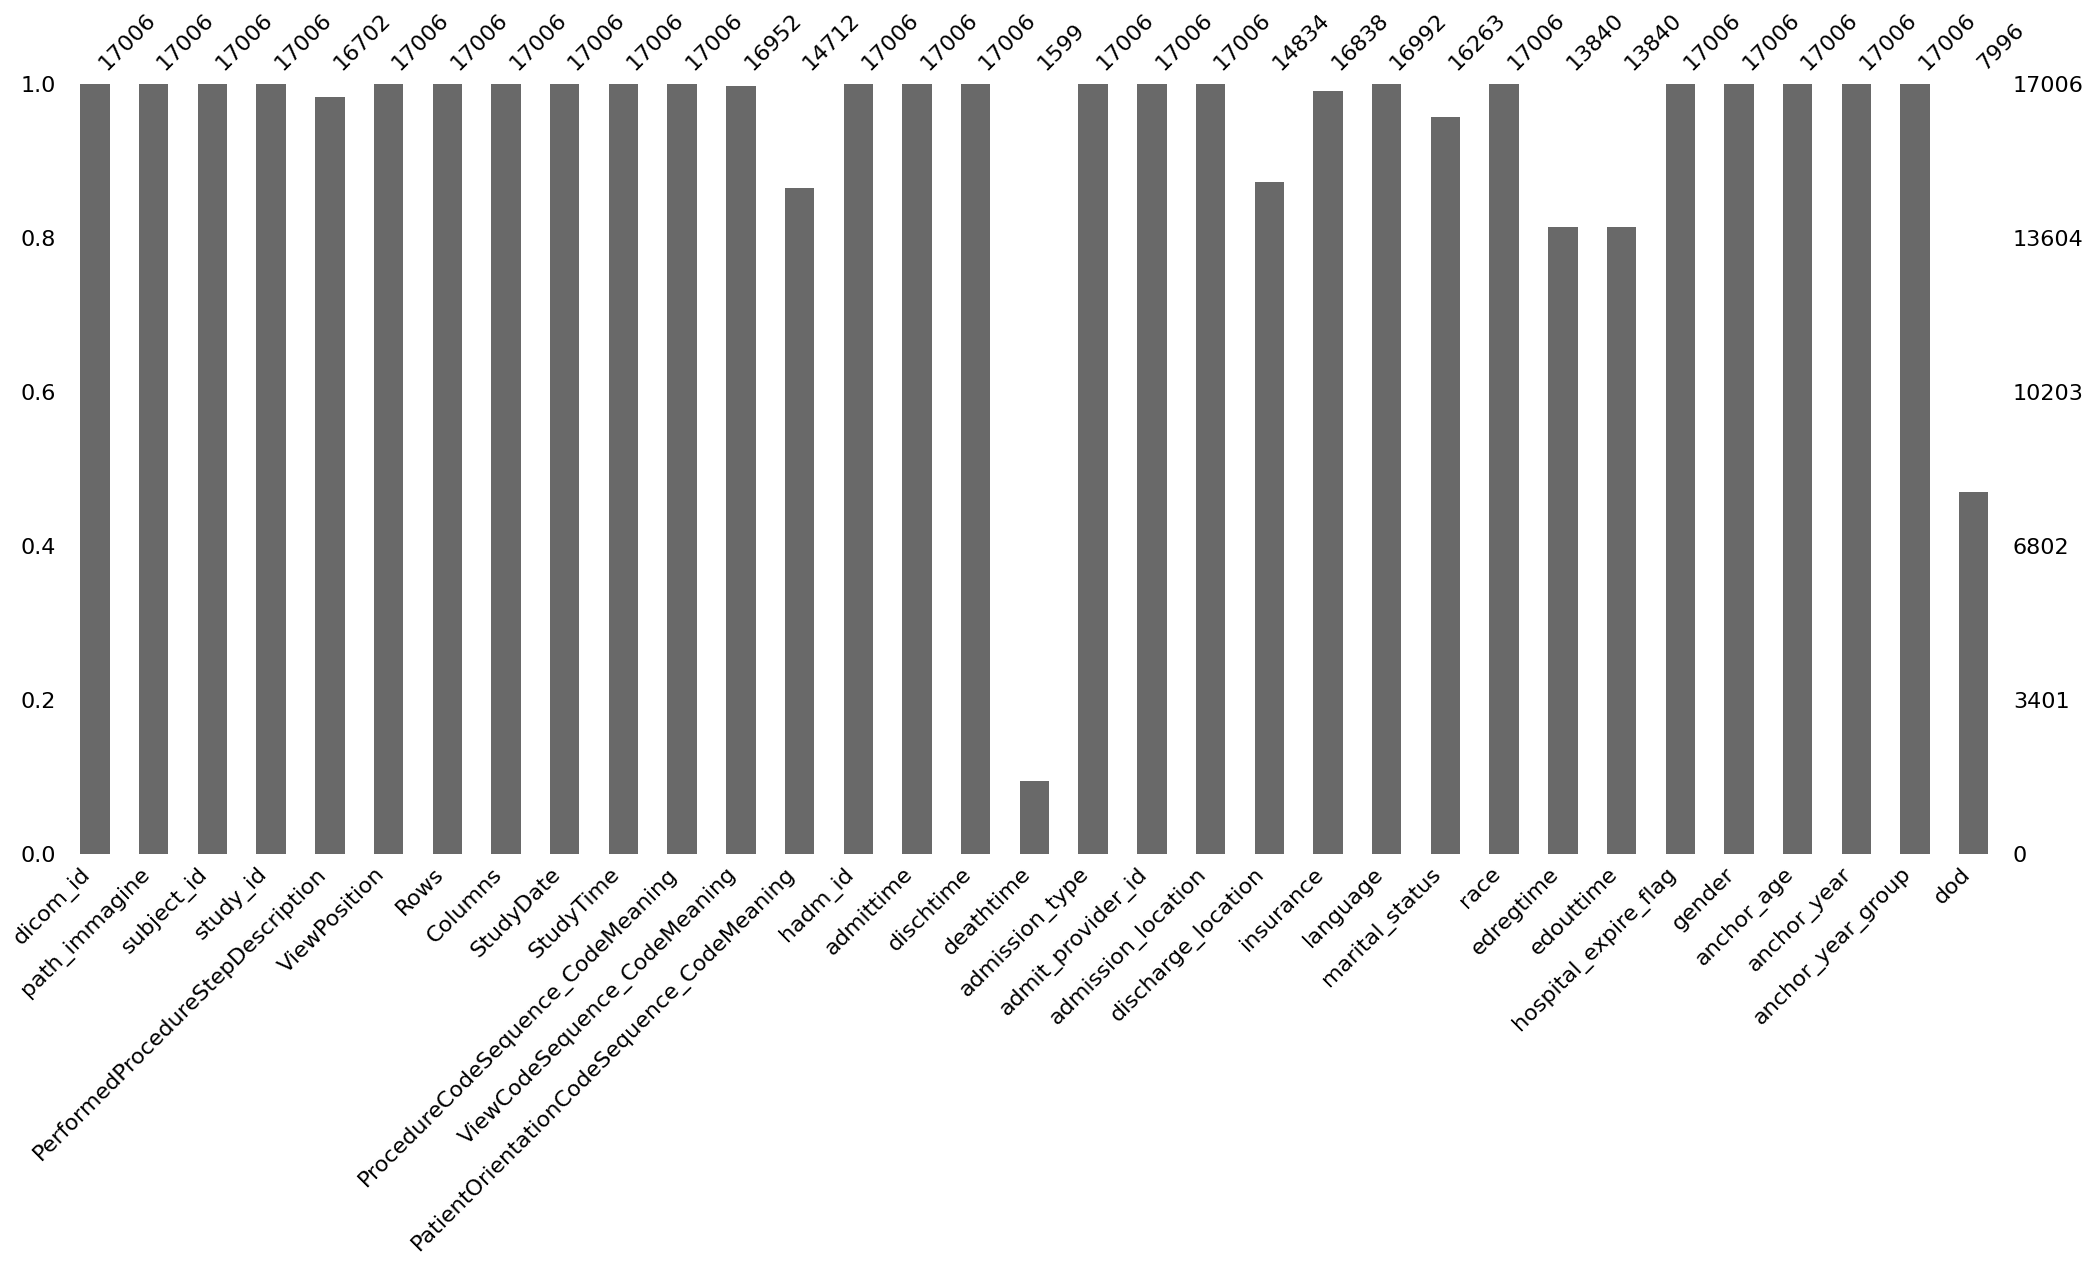

In [90]:
msno.bar(dataset)
plt.show()

In [91]:
diagnosi = pd.read_csv("data/mimic-iv-3.1/hosp/diagnoses_icd.csv")
diagnosi

,subject_id,hadm_id,seq_num,icd_code,icd_version
0,10000032,22595853,1,5723,9
1,10000032,22595853,2,78959,9
2,10000032,22595853,3,5715,9
3,10000032,22595853,4,07070,9
4,10000032,22595853,5,496,9
...,...,...,...,...,...
6364483,19999987,23865745,7,41401,9
6364484,19999987,23865745,8,78039,9
6364485,19999987,23865745,9,0413,9
6364486,19999987,23865745,10,36846,9


In [92]:
tumori = pd.read_csv("data/masse_tumorali_icd.csv")
tumori

,icd_code,icd_version,long_title
0,05922,9,Yaba monkey tumor virus
1,1400,9,"Malignant neoplasm of upper lip, vermilion border"
2,1401,9,"Malignant neoplasm of lower lip, vermilion border"
3,1403,9,"Malignant neoplasm of upper lip, inner aspect"
4,1404,9,"Malignant neoplasm of lower lip, inner aspect"
...,...,...,...
3067,Z8601,10,Personal history of benign neoplasm
3068,Z86011,10,Personal history of benign neoplasm of the brain
3069,Z86012,10,Personal history of benign carcinoid tumor
3070,Z86018,10,Personal history of other benign neoplasm


In [93]:
filtro = tumori[tumori['icd_version'] == 9]
codici_9 = filtro['icd_code'].to_list()
filtro = tumori[tumori['icd_version'] == 10]
codici_10 = filtro['icd_code'].to_list()

In [94]:
versioni_per_ricovero = diagnosi.groupby('hadm_id')['icd_version'].nunique()
misti = versioni_per_ricovero[versioni_per_ricovero > 1]
print(f"Ricoveri con versioni miste: {len(misti)}")

Ricoveri con versioni miste: 10


In [95]:
set_9 = set(tumori[tumori['icd_version'] == 9]['icd_code'])
set_10 = set(tumori[tumori['icd_version'] == 10]['icd_code'])

# Funzione di controllo "cross-version"
def controlla_tumore(row):
    if row['icd_version'] == 9:
        return 1 if row['icd_code'] in set_9 else 0
    if row['icd_version'] == 10:
        return 1 if row['icd_code'] in set_10 else 0
    return 0

diagnosi['is_tumor'] = diagnosi.apply(controlla_tumore, axis=1)
pivot_tumori = diagnosi.groupby(['subject_id', 'hadm_id'])['is_tumor'].max().reset_index()
pivot_tumori.columns = ['subject_id', 'hadm_id', 'target']

In [96]:
pivot_tumori

,subject_id,hadm_id,target
0,10000032,22595853,0
1,10000032,22841357,0
2,10000032,25742920,0
3,10000032,29079034,0
4,10000068,25022803,0
...,...,...,...
545492,19999828,25744818,0
545493,19999828,29734428,0
545494,19999840,21033226,0
545495,19999840,26071774,0


In [97]:
dataset = dataset.merge(pivot_tumori, how='inner', on=['subject_id', 'hadm_id'])
dataset

,dicom_id,path_immagine,subject_id,study_id,PerformedProcedureStepDescription,ViewPosition,Rows,Columns,StudyDate,StudyTime,...,race,edregtime,edouttime,hospital_expire_flag,gender,anchor_age,anchor_year,anchor_year_group,dod,target
0,62456122-1887ff8c-ef1cba37-270fe1ac-c88ef7fc,data/MIMIC_SUPER_RES_24K/62456122-1887ff8c-ef1...,16994397,52464683,CHEST (PORTABLE AP),AP,2539,3050,2113-07-01,170824.250,...,WHITE,2113-06-28 12:38:00,2113-06-28 22:03:00,0,F,78,2111,2011 - 2013,2113-07-27,1
1,064741c9-95255009-ae0c53ee-ccb54164-21b77bbb,data/MIMIC_SUPER_RES_24K/064741c9-95255009-ae0...,16012667,50941182,CHEST (PORTABLE AP),AP,3035,2539,2132-06-11,33907.343,...,OTHER,2132-06-05 18:16:00,2132-06-05 21:50:00,0,F,41,2132,2011 - 2013,NaN,0
2,2150ba84-0f87ae6f-a7132d8e-8b02fb6c-99745702,data/MIMIC_SUPER_RES_24K/2150ba84-0f87ae6f-a71...,17686783,50124464,CHEST (PORTABLE AP),AP,3056,2544,2172-02-09,51446.375,...,WHITE,2172-02-05 18:09:00,2172-02-05 22:15:00,1,F,52,2171,2011 - 2013,2172-02-13,1
3,ce03622b-d32e18d5-f668bc71-a8ac7266-adb2821b,data/MIMIC_SUPER_RES_24K/ce03622b-d32e18d5-f66...,10901772,53239060,CHEST (PA AND LAT) PORT,AP,2539,3050,2152-02-22,101645.890,...,WHITE,2152-02-19 05:56:00,2152-02-19 12:22:00,0,F,46,2146,2008 - 2010,2158-03-18,0
4,d146ed29-c6311af8-d3955557-d50b5f47-aa6bd854,data/MIMIC_SUPER_RES_24K/d146ed29-c6311af8-d39...,19908221,55173516,CHEST (PA AND LAT),PA,3056,2544,2142-12-07,82721.953,...,WHITE,2142-12-07 06:49:00,2142-12-07 18:54:00,0,M,62,2141,2014 - 2016,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16998,a7606ee8-17450105-f8990658-0c313cf4-62950ec5,data/MIMIC_SUPER_RES_24K/a7606ee8-17450105-f89...,17420936,58826820,CHEST (PA AND LAT),PA,3056,2544,2134-11-23,11637.703,...,BLACK/AFRICAN AMERICAN,2134-11-23 00:00:00,2134-11-23 05:46:00,0,M,53,2133,2008 - 2010,NaN,0
16999,eb76f199-dc94ddad-e7095f97-8671879f-4606de18,data/MIMIC_SUPER_RES_24K/eb76f199-dc94ddad-e70...,14522445,57330720,CHEST (PA AND LAT),PA,2544,3056,2165-10-24,185516.984,...,BLACK/AFRICAN AMERICAN,2165-10-24 16:01:00,2165-10-24 19:30:00,0,M,41,2165,2011 - 2013,NaN,0
17000,f2c56131-41b8d79c-8c49cff3-3c3fa85d-9bf49e1a,data/MIMIC_SUPER_RES_24K/f2c56131-41b8d79c-8c4...,11545313,59904294,CHEST (PA AND LAT),AP,3056,2544,2168-07-06,143016.859,...,BLACK/AFRICAN AMERICAN,2168-07-06 13:10:00,2168-07-06 21:27:00,0,F,91,2161,2008 - 2010,2169-06-04,1
17001,4a33432b-d891a4e8-44a53063-4e1b08bf-dd30ca6a,data/MIMIC_SUPER_RES_24K/4a33432b-d891a4e8-44a...,12885435,52596566,CHEST (PORTABLE AP),AP,3056,2544,2127-01-08,215121.656,...,WHITE,2127-01-03 15:32:00,2127-01-03 18:31:00,0,M,75,2125,2011 - 2013,2129-02-08,0


In [98]:
omr = pd.read_csv("data/mimic-iv-3.1/hosp/omr.csv")
omr['chartdate'] = pd.to_datetime(omr['chartdate'], errors='coerce')
omr

,subject_id,chartdate,seq_num,result_name,result_value
0,10000032,2180-04-27,1,Blood Pressure,110/65
1,10000032,2180-04-27,1,Weight (Lbs),94
2,10000032,2180-05-07,1,BMI (kg/m2),18.0
3,10000032,2180-05-07,1,Height (Inches),60
4,10000032,2180-05-07,1,Weight (Lbs),92.15
...,...,...,...,...,...
7753022,19999828,2148-02-26,1,Blood Pressure,115/79
7753023,19999828,2148-04-29,1,Blood Pressure,105/67
7753024,19999828,2148-07-22,1,Blood Pressure,104/76
7753025,19999828,2148-10-19,1,Blood Pressure,112/73


In [99]:
omr_pivot = omr.pivot_table(
    index=['subject_id', 'chartdate'],
    columns='result_name',
    values='result_value',
    aggfunc='first'
).reset_index()
omr_pivot

result_name,subject_id,chartdate,BMI,BMI (kg/m2),Blood Pressure,Blood Pressure Lying,Blood Pressure Sitting,Blood Pressure Standing,Blood Pressure Standing (1 min),Blood Pressure Standing (3 mins),Height,Height (Inches),Weight,Weight (Lbs),eGFR
0,10000032,2180-04-27,NaN,NaN,110/65,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,94,NaN
1,10000032,2180-05-07,NaN,18.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60,NaN,92.15,NaN
2,10000032,2180-05-25,NaN,18.6,106/60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,95,NaN
3,10000032,2180-06-01,NaN,18.7,121/77,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,95.7,NaN
4,10000032,2180-06-22,NaN,18.9,100/60,NaN,NaN,NaN,NaN,NaN,NaN,60,NaN,97,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2916132,19999828,2148-02-26,NaN,NaN,115/79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2916133,19999828,2148-04-29,NaN,NaN,105/67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2916134,19999828,2148-07-22,NaN,NaN,104/76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2916135,19999828,2148-10-19,NaN,NaN,112/73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: xlabel='result_name'>

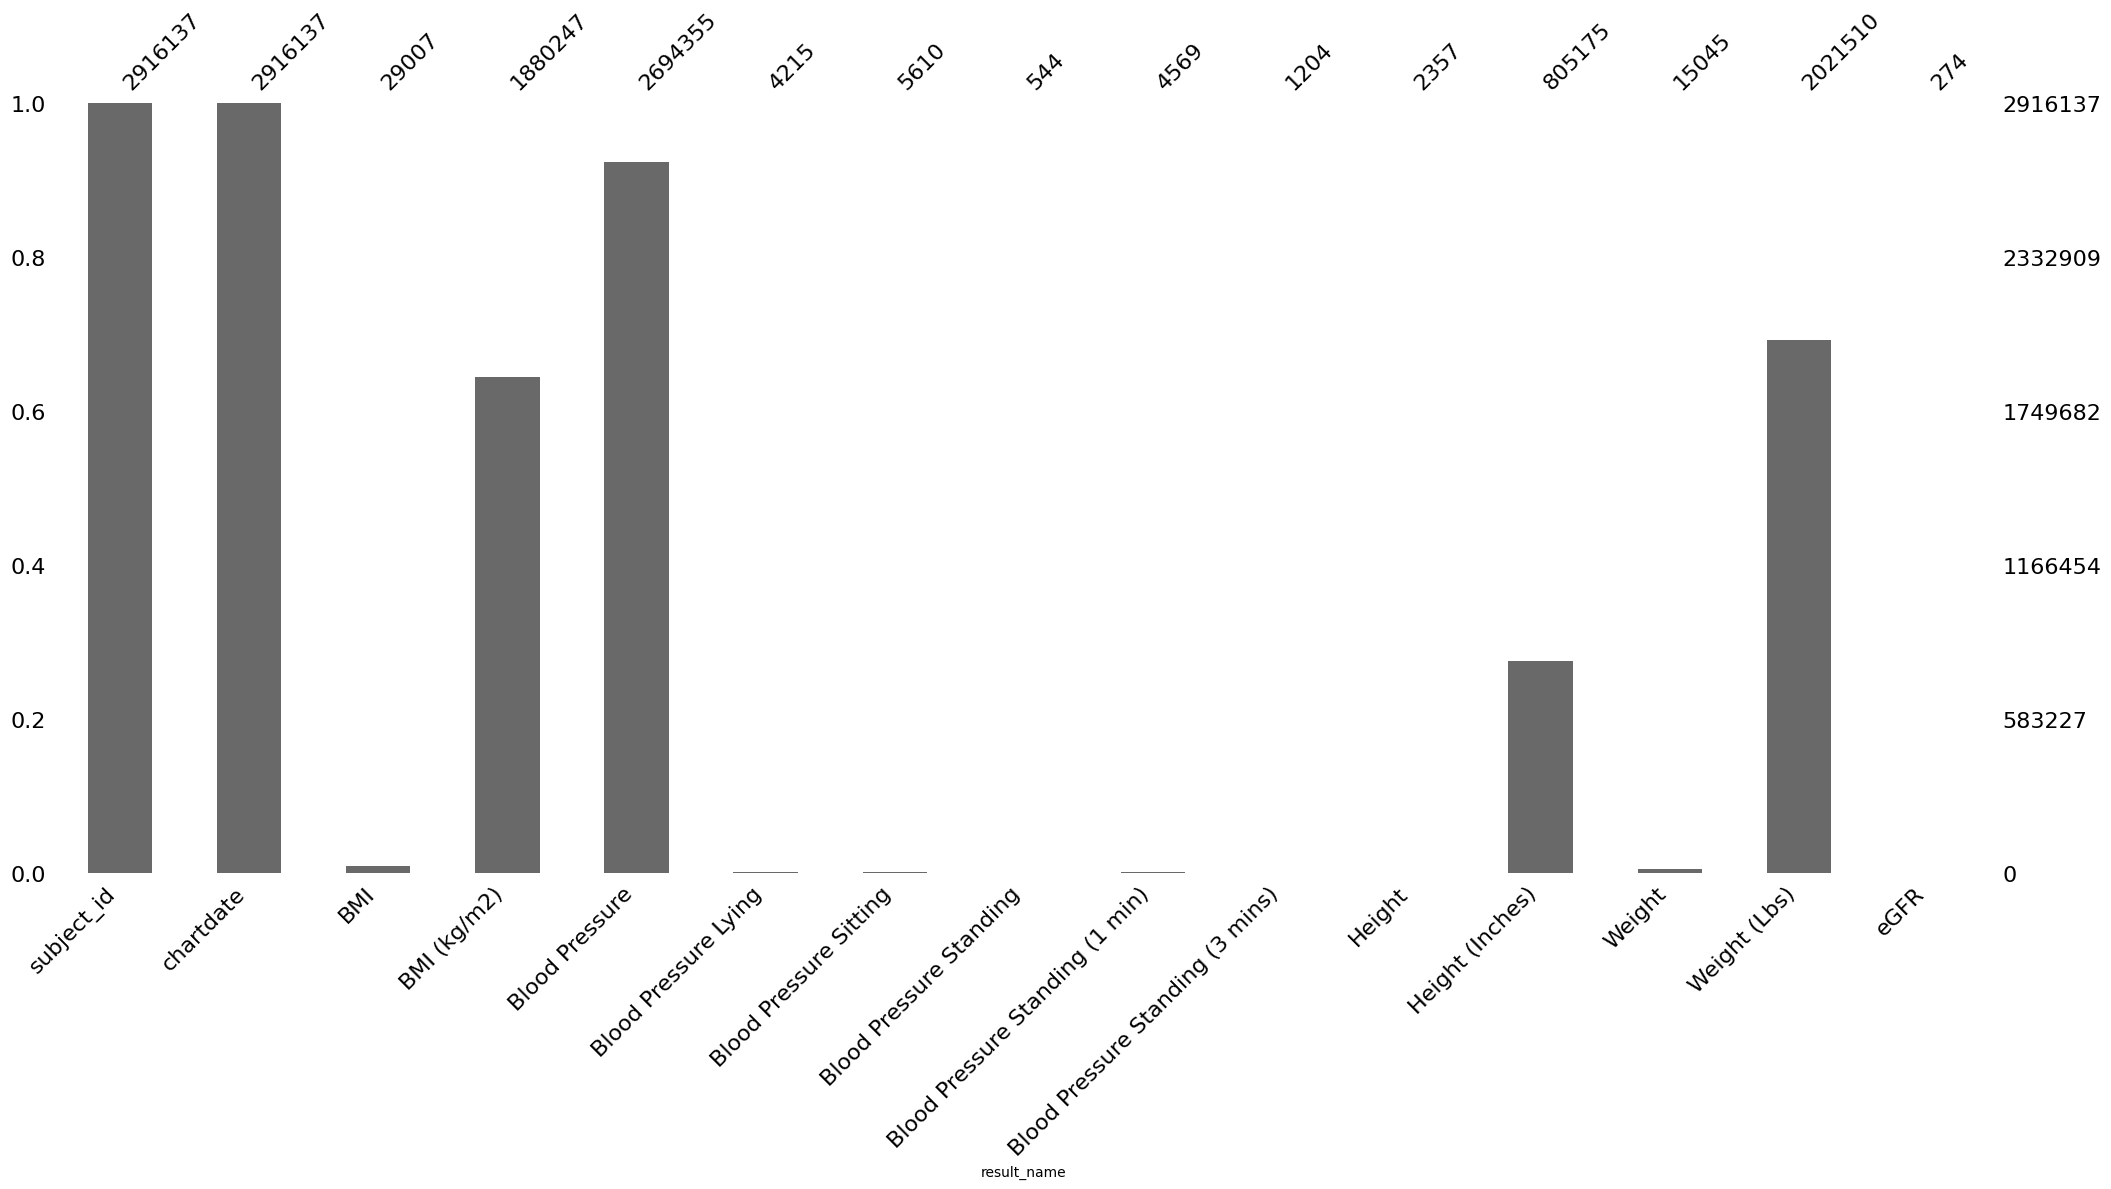

In [100]:
msno.bar(omr_pivot)

In [101]:
print(omr_pivot[['Height', 'Height (Inches)']].describe())

result_name Height Height (Inches)
count         2357          805175
unique         124            1680
top          64.50              64
freq           183           50673


In [102]:
print(omr_pivot[['Weight', 'Weight (Lbs)']].describe())

result_name  Weight Weight (Lbs)
count         15045      2021510
unique         1871        11070
top          150.00          150
freq            139        17442


In [103]:
INCH_TO_CM = 2.54
LB_TO_KG = 0.453592
omr_pivot['Height'] = omr_pivot['Height (Inches)'].fillna(omr_pivot['Height'])
omr_pivot['Weight'] = omr_pivot['Weight (Lbs)'].fillna(omr_pivot['Weight'])
omr_pivot['BMI'] = omr_pivot['BMI (kg/m2)'].fillna(omr_pivot['BMI'])
omr_pivot = omr_pivot.drop(columns=['Height (Inches)', 'Weight (Lbs)', 'BMI (kg/m2)'])
omr_pivot['Height'] = pd.to_numeric(omr_pivot['Height'], errors='coerce')
omr_pivot['Weight'] = pd.to_numeric(omr_pivot['Weight'], errors='coerce')
omr_pivot['Height'] = omr_pivot['Height'] * INCH_TO_CM
omr_pivot['Weight'] = omr_pivot['Weight'] * LB_TO_KG
# Split della Pressione Arteriosa in Sistolica e Diastolica per l'imputazione
omr_pivot[['Systolic', 'Diastolic']] = omr_pivot['Blood Pressure'].str.split('/', expand=True).astype(float)
omr_pivot = omr_pivot.drop(columns=['Blood Pressure', 'Blood Pressure Lying', 'Blood Pressure Sitting', 'Blood Pressure Standing'])
omr_pivot['BMI'] = (omr_pivot['Weight'] / ((omr_pivot['Height'] / 100) ** 2)).round(1)
omr_pivot['Height'] = omr_pivot['Height'].round(1)
omr_pivot['Weight'] = omr_pivot['Weight'].round(1)

omr_pivot

result_name,subject_id,chartdate,BMI,Blood Pressure Standing (1 min),Blood Pressure Standing (3 mins),Height,Weight,eGFR,Systolic,Diastolic
0,10000032,2180-04-27,NaN,NaN,NaN,NaN,42.6,NaN,110.0,65.0
1,10000032,2180-05-07,18.0,NaN,NaN,152.4,41.8,NaN,NaN,NaN
2,10000032,2180-05-25,NaN,NaN,NaN,NaN,43.1,NaN,106.0,60.0
3,10000032,2180-06-01,NaN,NaN,NaN,NaN,43.4,NaN,121.0,77.0
4,10000032,2180-06-22,18.9,NaN,NaN,152.4,44.0,NaN,100.0,60.0
...,...,...,...,...,...,...,...,...,...,...
2916132,19999828,2148-02-26,NaN,NaN,NaN,NaN,NaN,NaN,115.0,79.0
2916133,19999828,2148-04-29,NaN,NaN,NaN,NaN,NaN,NaN,105.0,67.0
2916134,19999828,2148-07-22,NaN,NaN,NaN,NaN,NaN,NaN,104.0,76.0
2916135,19999828,2148-10-19,NaN,NaN,NaN,NaN,NaN,NaN,112.0,73.0


In [104]:
colonne_utili = [
    'subject_id', 
    'chartdate', 
    'Height', 
    'Weight', 
    'BMI', 
    'Systolic', 
    'Diastolic'
]

omr_pivot = omr_pivot[colonne_utili].copy()

# Un piccolo check: ricalcoliamo il BMI per sicurezza dove abbiamo Peso e Altezza
# Formula: kg / (m^2)
mask = omr_pivot['Height'].notna() & omr_pivot['Weight'].notna()
omr_pivot.loc[mask, 'BMI'] = (
   omr_pivot['Weight'] / ((omr_pivot['Height'] / 100) ** 2)
).round(1)
omr_pivot

result_name,subject_id,chartdate,Height,Weight,BMI,Systolic,Diastolic
0,10000032,2180-04-27,NaN,42.6,NaN,110.0,65.0
1,10000032,2180-05-07,152.4,41.8,18.0,NaN,NaN
2,10000032,2180-05-25,NaN,43.1,NaN,106.0,60.0
3,10000032,2180-06-01,NaN,43.4,NaN,121.0,77.0
4,10000032,2180-06-22,152.4,44.0,18.9,100.0,60.0
...,...,...,...,...,...,...,...
2916132,19999828,2148-02-26,NaN,NaN,NaN,115.0,79.0
2916133,19999828,2148-04-29,NaN,NaN,NaN,105.0,67.0
2916134,19999828,2148-07-22,NaN,NaN,NaN,104.0,76.0
2916135,19999828,2148-10-19,NaN,NaN,NaN,112.0,73.0


<Axes: xlabel='result_name'>

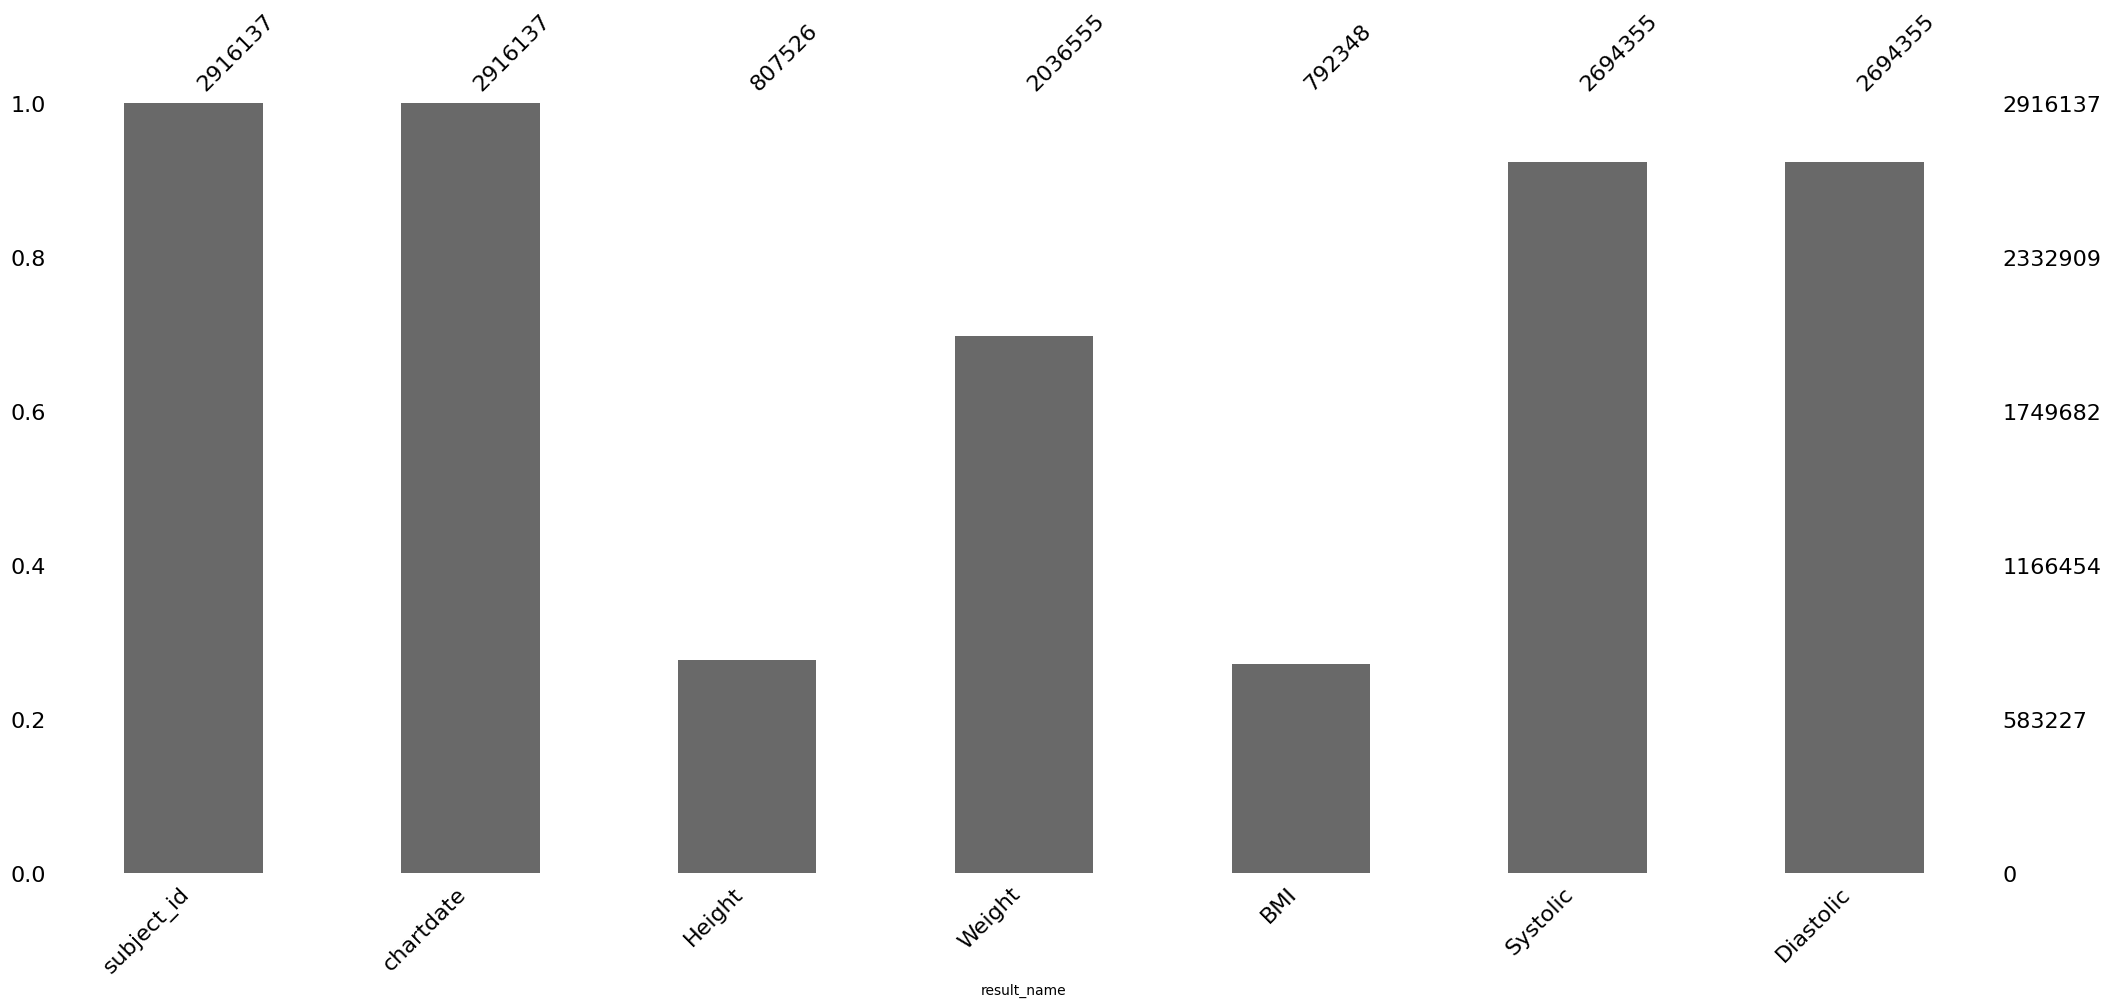

In [105]:
msno.bar(omr_pivot)

In [106]:
dataset = dataset.sort_values('StudyDate')
omr_pivot = omr_pivot.sort_values('chartdate')
dataset_finale = pd.merge_asof(
    dataset, 
    omr_pivot,
    left_on='StudyDate',
    right_on='chartdate',
    by='subject_id',
    direction='nearest',
)
dataset_finale

,dicom_id,path_immagine,subject_id,study_id,PerformedProcedureStepDescription,ViewPosition,Rows,Columns,StudyDate,StudyTime,...,anchor_year,anchor_year_group,dod,target,chartdate,Height,Weight,BMI,Systolic,Diastolic
0,1b9352eb-9ae051ae-8fd2c6ad-165db0b8-e74211a2,data/MIMIC_SUPER_RES_24K/1b9352eb-9ae051ae-8fd...,17195991,59967459,CHEST (PORTABLE AP),AP,2544,2429,2110-01-12,110815.593,...,2110,2011 - 2013,NaN,1,2113-05-07,157.5,91.2,36.8,NaN,NaN
1,5026e6e7-88623192-b3341cef-3360dd07-ed93935c,data/MIMIC_SUPER_RES_24K/5026e6e7-88623192-b33...,10582595,55287293,CHEST (PORTABLE AP),AP,3056,2544,2110-02-15,145715.140,...,2110,2011 - 2013,NaN,0,2110-03-03,157.5,50.8,20.5,120.0,70.0
2,738d88c6-6f27d184-90e581eb-24a4df43-a24a461f,data/MIMIC_SUPER_RES_24K/738d88c6-6f27d184-90e...,19170541,59722794,CHEST (PORTABLE AP),AP,3056,2544,2110-02-16,90850.828,...,2110,2011 - 2013,NaN,0,2110-03-23,170.2,83.9,29.0,118.0,76.0
3,0dcd5d5f-11abf690-098cf848-7eca5faa-43f9aed7,data/MIMIC_SUPER_RES_24K/0dcd5d5f-11abf690-098...,13721591,51456576,CHEST (PORTABLE AP),AP,2539,2920,2110-02-18,34915.500,...,2110,2014 - 2016,NaN,1,2110-02-09,162.6,110.7,41.9,NaN,NaN
4,508fa2a6-6b03a079-114b496d-7a21f61d-0f0bca11,data/MIMIC_SUPER_RES_24K/508fa2a6-6b03a079-114...,17282717,51958155,CHEST (PORTABLE AP),AP,2539,3050,2110-03-04,154743.937,...,2110,2011 - 2013,NaN,0,NaT,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16998,a4fd21e2-262e3b5f-cf7fe4f2-80f05fc3-c24146f3,data/MIMIC_SUPER_RES_24K/a4fd21e2-262e3b5f-cf7...,18775665,55047642,CHEST (PORTABLE AP),AP,3056,2544,2207-10-07,153045.421,...,2204,2011 - 2013,2207-10-11,0,2207-09-25,145.9,47.2,22.2,150.0,70.0
16999,321690cd-c22e8b19-11728373-3cfa75c8-1a9f8ddf,data/MIMIC_SUPER_RES_24K/321690cd-c22e8b19-117...,14434519,56251976,CHEST (PORTABLE AP),AP,3056,2544,2207-12-30,80953.312,...,2202,2008 - 2010,NaN,1,2207-12-26,NaN,142.9,NaN,NaN,NaN
17000,9a2dd286-ced0ba1d-c08a82fe-6d73d532-7036e5f8,data/MIMIC_SUPER_RES_24K/9a2dd286-ced0ba1d-c08...,13364829,52001154,CHEST (PORTABLE AP),AP,2539,2553,2208-01-03,102956.890,...,2199,2008 - 2010,2208-01-13,1,2208-01-03,NaN,136.5,NaN,NaN,NaN
17001,ae6fc78f-e0e1e60e-5d9bcc2a-d7ae3df1-a5524992,data/MIMIC_SUPER_RES_24K/ae6fc78f-e0e1e60e-5d9...,15211528,57616834,CHEST (PORTABLE AP),AP,2544,3056,2208-02-08,234449.328,...,2208,2014 - 2016,NaN,0,2208-02-08,162.6,70.0,26.5,NaN,NaN


<Axes: >

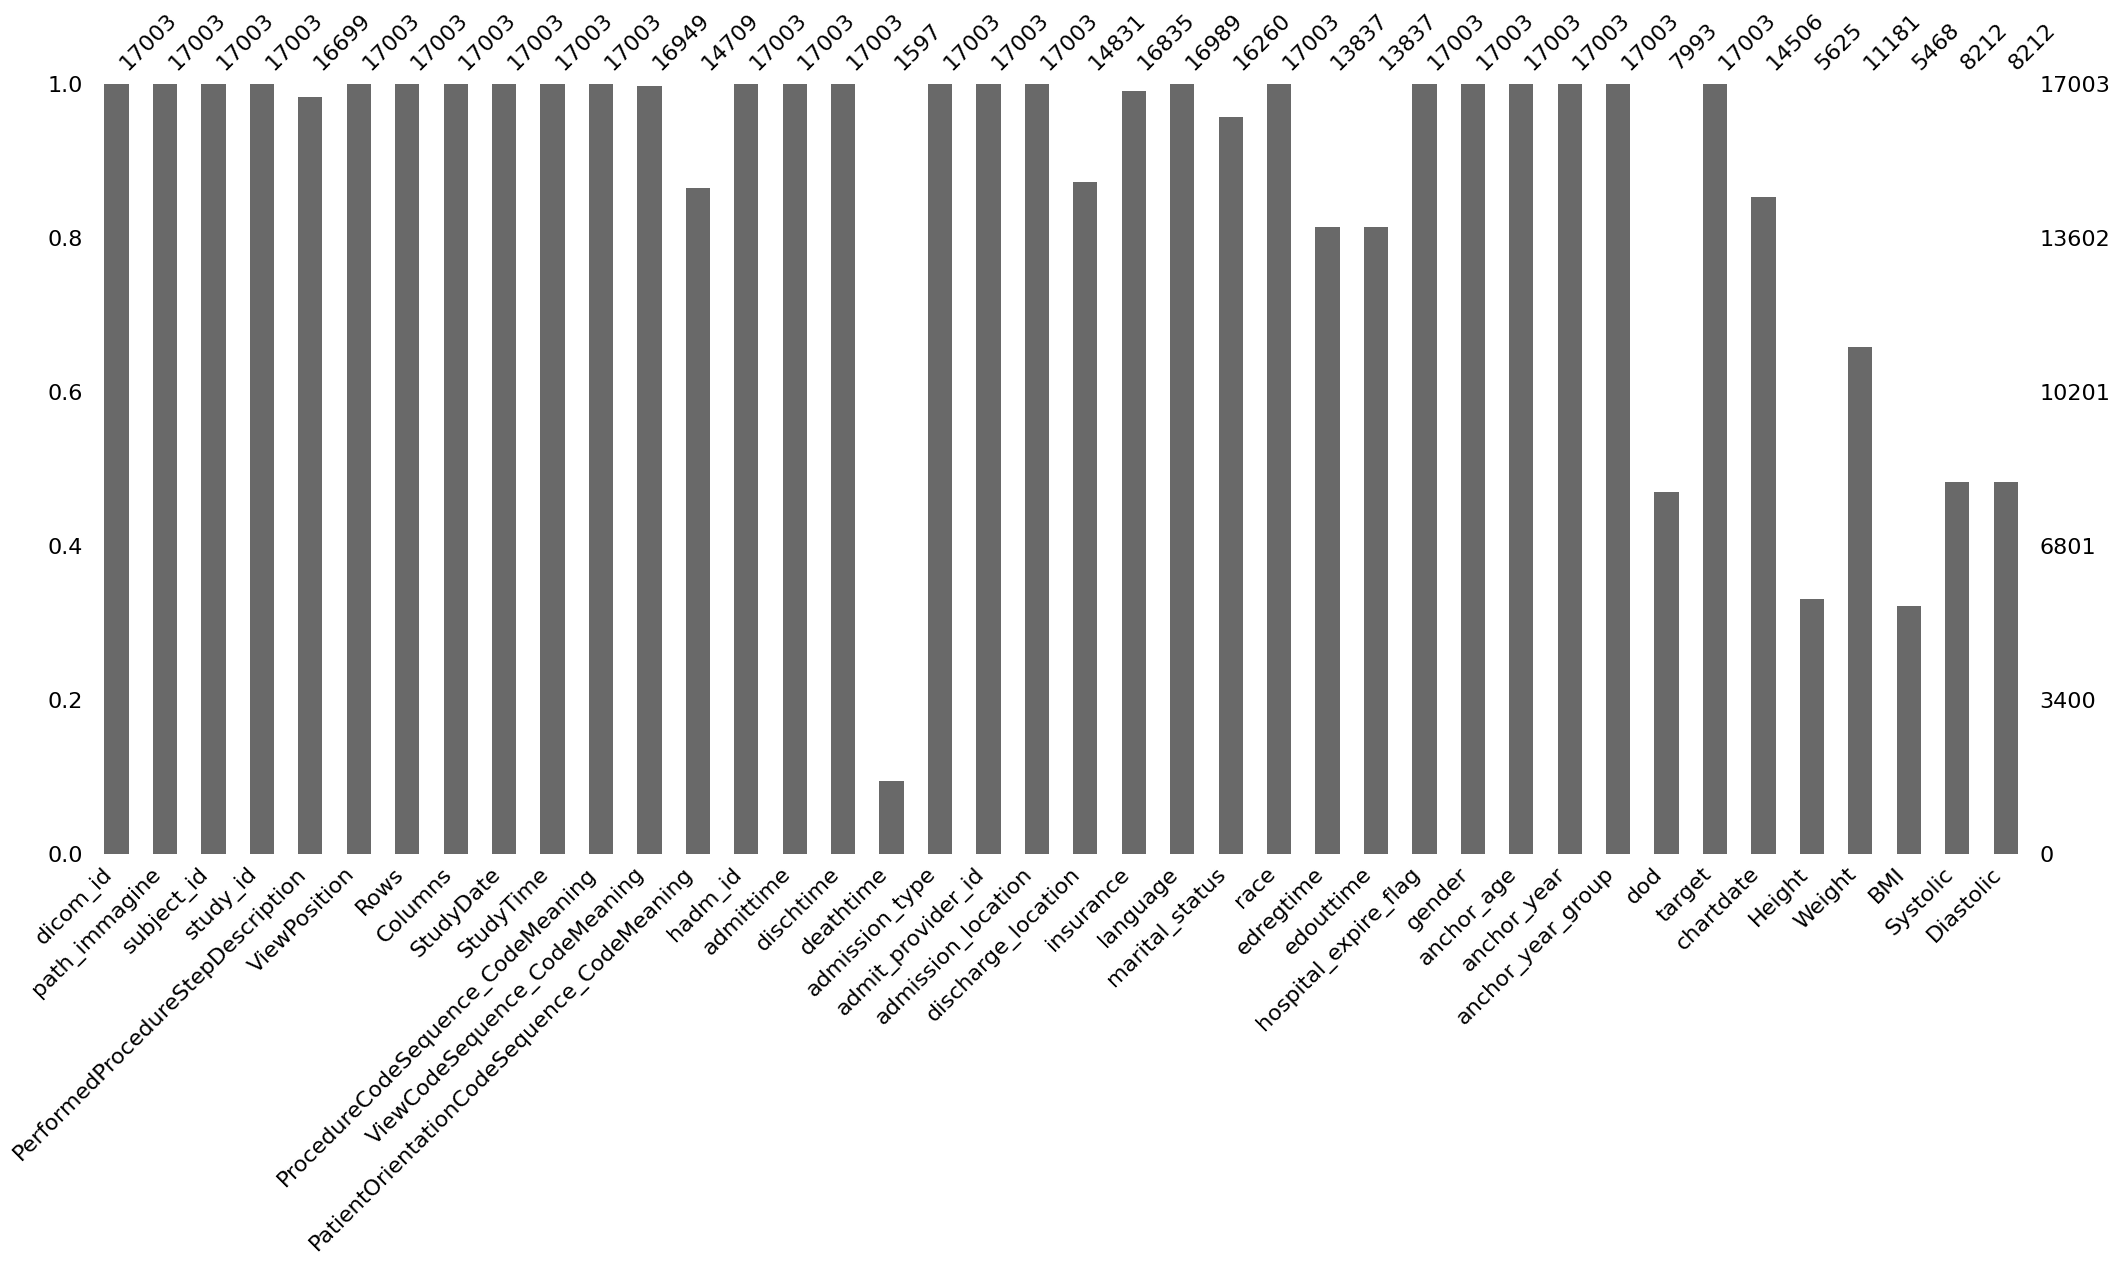

In [107]:
msno.bar(dataset_finale)

In [108]:
dataset_finale = dataset_finale.drop(columns=['Height', 'BMI'])
dataset_finale

,dicom_id,path_immagine,subject_id,study_id,PerformedProcedureStepDescription,ViewPosition,Rows,Columns,StudyDate,StudyTime,...,gender,anchor_age,anchor_year,anchor_year_group,dod,target,chartdate,Weight,Systolic,Diastolic
0,1b9352eb-9ae051ae-8fd2c6ad-165db0b8-e74211a2,data/MIMIC_SUPER_RES_24K/1b9352eb-9ae051ae-8fd...,17195991,59967459,CHEST (PORTABLE AP),AP,2544,2429,2110-01-12,110815.593,...,F,61,2110,2011 - 2013,NaN,1,2113-05-07,91.2,NaN,NaN
1,5026e6e7-88623192-b3341cef-3360dd07-ed93935c,data/MIMIC_SUPER_RES_24K/5026e6e7-88623192-b33...,10582595,55287293,CHEST (PORTABLE AP),AP,3056,2544,2110-02-15,145715.140,...,F,91,2110,2011 - 2013,NaN,0,2110-03-03,50.8,120.0,70.0
2,738d88c6-6f27d184-90e581eb-24a4df43-a24a461f,data/MIMIC_SUPER_RES_24K/738d88c6-6f27d184-90e...,19170541,59722794,CHEST (PORTABLE AP),AP,3056,2544,2110-02-16,90850.828,...,M,44,2110,2011 - 2013,NaN,0,2110-03-23,83.9,118.0,76.0
3,0dcd5d5f-11abf690-098cf848-7eca5faa-43f9aed7,data/MIMIC_SUPER_RES_24K/0dcd5d5f-11abf690-098...,13721591,51456576,CHEST (PORTABLE AP),AP,2539,2920,2110-02-18,34915.500,...,F,65,2110,2014 - 2016,NaN,1,2110-02-09,110.7,NaN,NaN
4,508fa2a6-6b03a079-114b496d-7a21f61d-0f0bca11,data/MIMIC_SUPER_RES_24K/508fa2a6-6b03a079-114...,17282717,51958155,CHEST (PORTABLE AP),AP,2539,3050,2110-03-04,154743.937,...,M,66,2110,2011 - 2013,NaN,0,NaT,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16998,a4fd21e2-262e3b5f-cf7fe4f2-80f05fc3-c24146f3,data/MIMIC_SUPER_RES_24K/a4fd21e2-262e3b5f-cf7...,18775665,55047642,CHEST (PORTABLE AP),AP,3056,2544,2207-10-07,153045.421,...,F,81,2204,2011 - 2013,2207-10-11,0,2207-09-25,47.2,150.0,70.0
16999,321690cd-c22e8b19-11728373-3cfa75c8-1a9f8ddf,data/MIMIC_SUPER_RES_24K/321690cd-c22e8b19-117...,14434519,56251976,CHEST (PORTABLE AP),AP,3056,2544,2207-12-30,80953.312,...,F,59,2202,2008 - 2010,NaN,1,2207-12-26,142.9,NaN,NaN
17000,9a2dd286-ced0ba1d-c08a82fe-6d73d532-7036e5f8,data/MIMIC_SUPER_RES_24K/9a2dd286-ced0ba1d-c08...,13364829,52001154,CHEST (PORTABLE AP),AP,2539,2553,2208-01-03,102956.890,...,F,39,2199,2008 - 2010,2208-01-13,1,2208-01-03,136.5,NaN,NaN
17001,ae6fc78f-e0e1e60e-5d9bcc2a-d7ae3df1-a5524992,data/MIMIC_SUPER_RES_24K/ae6fc78f-e0e1e60e-5d9...,15211528,57616834,CHEST (PORTABLE AP),AP,2544,3056,2208-02-08,234449.328,...,F,77,2208,2014 - 2016,NaN,0,2208-02-08,70.0,NaN,NaN


In [109]:
dataset_finale['is_deceased'] = dataset_finale['dod'].notna().astype(int)
dataset_finale = dataset_finale.drop(columns=['dod', 'deathtime'])
dataset_finale

,dicom_id,path_immagine,subject_id,study_id,PerformedProcedureStepDescription,ViewPosition,Rows,Columns,StudyDate,StudyTime,...,gender,anchor_age,anchor_year,anchor_year_group,target,chartdate,Weight,Systolic,Diastolic,is_deceased
0,1b9352eb-9ae051ae-8fd2c6ad-165db0b8-e74211a2,data/MIMIC_SUPER_RES_24K/1b9352eb-9ae051ae-8fd...,17195991,59967459,CHEST (PORTABLE AP),AP,2544,2429,2110-01-12,110815.593,...,F,61,2110,2011 - 2013,1,2113-05-07,91.2,NaN,NaN,0
1,5026e6e7-88623192-b3341cef-3360dd07-ed93935c,data/MIMIC_SUPER_RES_24K/5026e6e7-88623192-b33...,10582595,55287293,CHEST (PORTABLE AP),AP,3056,2544,2110-02-15,145715.140,...,F,91,2110,2011 - 2013,0,2110-03-03,50.8,120.0,70.0,0
2,738d88c6-6f27d184-90e581eb-24a4df43-a24a461f,data/MIMIC_SUPER_RES_24K/738d88c6-6f27d184-90e...,19170541,59722794,CHEST (PORTABLE AP),AP,3056,2544,2110-02-16,90850.828,...,M,44,2110,2011 - 2013,0,2110-03-23,83.9,118.0,76.0,0
3,0dcd5d5f-11abf690-098cf848-7eca5faa-43f9aed7,data/MIMIC_SUPER_RES_24K/0dcd5d5f-11abf690-098...,13721591,51456576,CHEST (PORTABLE AP),AP,2539,2920,2110-02-18,34915.500,...,F,65,2110,2014 - 2016,1,2110-02-09,110.7,NaN,NaN,0
4,508fa2a6-6b03a079-114b496d-7a21f61d-0f0bca11,data/MIMIC_SUPER_RES_24K/508fa2a6-6b03a079-114...,17282717,51958155,CHEST (PORTABLE AP),AP,2539,3050,2110-03-04,154743.937,...,M,66,2110,2011 - 2013,0,NaT,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16998,a4fd21e2-262e3b5f-cf7fe4f2-80f05fc3-c24146f3,data/MIMIC_SUPER_RES_24K/a4fd21e2-262e3b5f-cf7...,18775665,55047642,CHEST (PORTABLE AP),AP,3056,2544,2207-10-07,153045.421,...,F,81,2204,2011 - 2013,0,2207-09-25,47.2,150.0,70.0,1
16999,321690cd-c22e8b19-11728373-3cfa75c8-1a9f8ddf,data/MIMIC_SUPER_RES_24K/321690cd-c22e8b19-117...,14434519,56251976,CHEST (PORTABLE AP),AP,3056,2544,2207-12-30,80953.312,...,F,59,2202,2008 - 2010,1,2207-12-26,142.9,NaN,NaN,0
17000,9a2dd286-ced0ba1d-c08a82fe-6d73d532-7036e5f8,data/MIMIC_SUPER_RES_24K/9a2dd286-ced0ba1d-c08...,13364829,52001154,CHEST (PORTABLE AP),AP,2539,2553,2208-01-03,102956.890,...,F,39,2199,2008 - 2010,1,2208-01-03,136.5,NaN,NaN,1
17001,ae6fc78f-e0e1e60e-5d9bcc2a-d7ae3df1-a5524992,data/MIMIC_SUPER_RES_24K/ae6fc78f-e0e1e60e-5d9...,15211528,57616834,CHEST (PORTABLE AP),AP,2544,3056,2208-02-08,234449.328,...,F,77,2208,2014 - 2016,0,2208-02-08,70.0,NaN,NaN,0


In [110]:
dataset_finale.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17003 entries, 0 to 17002
Data columns (total 37 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   dicom_id                                    17003 non-null  object        
 1   path_immagine                               17003 non-null  object        
 2   subject_id                                  17003 non-null  int64         
 3   study_id                                    17003 non-null  int64         
 4   PerformedProcedureStepDescription           16699 non-null  object        
 5   ViewPosition                                17003 non-null  object        
 6   Rows                                        17003 non-null  int64         
 7   Columns                                     17003 non-null  int64         
 8   StudyDate                                   17003 non-null  datetime64[ns]
 9   StudyT

In [111]:
dataset_finale['admittime'] = pd.to_datetime(dataset_finale['admittime'], errors='coerce')
dataset_finale['dischtime'] = pd.to_datetime(dataset_finale['dischtime'], errors='coerce')
dataset_finale['length_of_stay_days'] = (dataset_finale['dischtime'] - dataset_finale['admittime']).dt.total_seconds() / (24 * 3600)
dataset_finale['length_of_stay_days'] = dataset_finale['length_of_stay_days'].round(1)
dataset_finale = dataset_finale.drop(
    columns=['admittime',
             'dischtime', 
             'edregtime', 
             'edouttime',
             'chartdate',
             'anchor_year',
             'anchor_year_group',
             'StudyDate',
             'StudyTime',
             'dicom_id',
             'subject_id',
             'study_id',
             'hadm_id'])
dataset_finale

,path_immagine,PerformedProcedureStepDescription,ViewPosition,Rows,Columns,ProcedureCodeSequence_CodeMeaning,ViewCodeSequence_CodeMeaning,PatientOrientationCodeSequence_CodeMeaning,admission_type,admit_provider_id,...,race,hospital_expire_flag,gender,anchor_age,target,Weight,Systolic,Diastolic,is_deceased,length_of_stay_days
0,data/MIMIC_SUPER_RES_24K/1b9352eb-9ae051ae-8fd...,CHEST (PORTABLE AP),AP,2544,2429,CHEST (PORTABLE AP),antero-posterior,NaN,EW EMER.,P33612,...,UNABLE TO OBTAIN,0,F,61,1,91.2,NaN,NaN,0,7.0
1,data/MIMIC_SUPER_RES_24K/5026e6e7-88623192-b33...,CHEST (PORTABLE AP),AP,3056,2544,CHEST (PORTABLE AP),antero-posterior,Erect,EW EMER.,P82C2A,...,WHITE,0,F,91,0,50.8,120.0,70.0,0,8.0
2,data/MIMIC_SUPER_RES_24K/738d88c6-6f27d184-90e...,CHEST (PORTABLE AP),AP,3056,2544,CHEST (PORTABLE AP),antero-posterior,Erect,EW EMER.,P82C2A,...,HISPANIC/LATINO - PUERTO RICAN,0,M,44,0,83.9,118.0,76.0,0,8.0
3,data/MIMIC_SUPER_RES_24K/0dcd5d5f-11abf690-098...,CHEST (PORTABLE AP),AP,2539,2920,CHEST (PORTABLE AP),antero-posterior,Erect,EW EMER.,P086OF,...,WHITE,0,F,65,1,110.7,NaN,NaN,0,13.0
4,data/MIMIC_SUPER_RES_24K/508fa2a6-6b03a079-114...,CHEST (PORTABLE AP),AP,2539,3050,CHEST (PORTABLE AP),antero-posterior,Erect,EW EMER.,P036NA,...,UNKNOWN,0,M,66,0,NaN,NaN,NaN,0,19.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16998,data/MIMIC_SUPER_RES_24K/a4fd21e2-262e3b5f-cf7...,CHEST (PORTABLE AP),AP,3056,2544,CHEST (PORTABLE AP),antero-posterior,Erect,EW EMER.,P05MOU,...,WHITE,1,F,81,0,47.2,150.0,70.0,1,4.0
16999,data/MIMIC_SUPER_RES_24K/321690cd-c22e8b19-117...,CHEST (PORTABLE AP),AP,3056,2544,CHEST (PORTABLE AP),antero-posterior,Erect,EW EMER.,P03ZWF,...,BLACK/AFRICAN AMERICAN,0,F,59,1,142.9,NaN,NaN,0,6.0
17000,data/MIMIC_SUPER_RES_24K/9a2dd286-ced0ba1d-c08...,CHEST (PORTABLE AP),AP,2539,2553,CHEST (PORTABLE AP),antero-posterior,Erect,EW EMER.,P23NUR,...,BLACK/AFRICAN AMERICAN,0,F,39,1,136.5,NaN,NaN,1,29.0
17001,data/MIMIC_SUPER_RES_24K/ae6fc78f-e0e1e60e-5d9...,CHEST (PORTABLE AP),AP,2544,3056,CHEST (PORTABLE AP),antero-posterior,Erect,EW EMER.,P55EL5,...,WHITE,0,F,77,0,70.0,NaN,NaN,0,9.0


<Axes: >

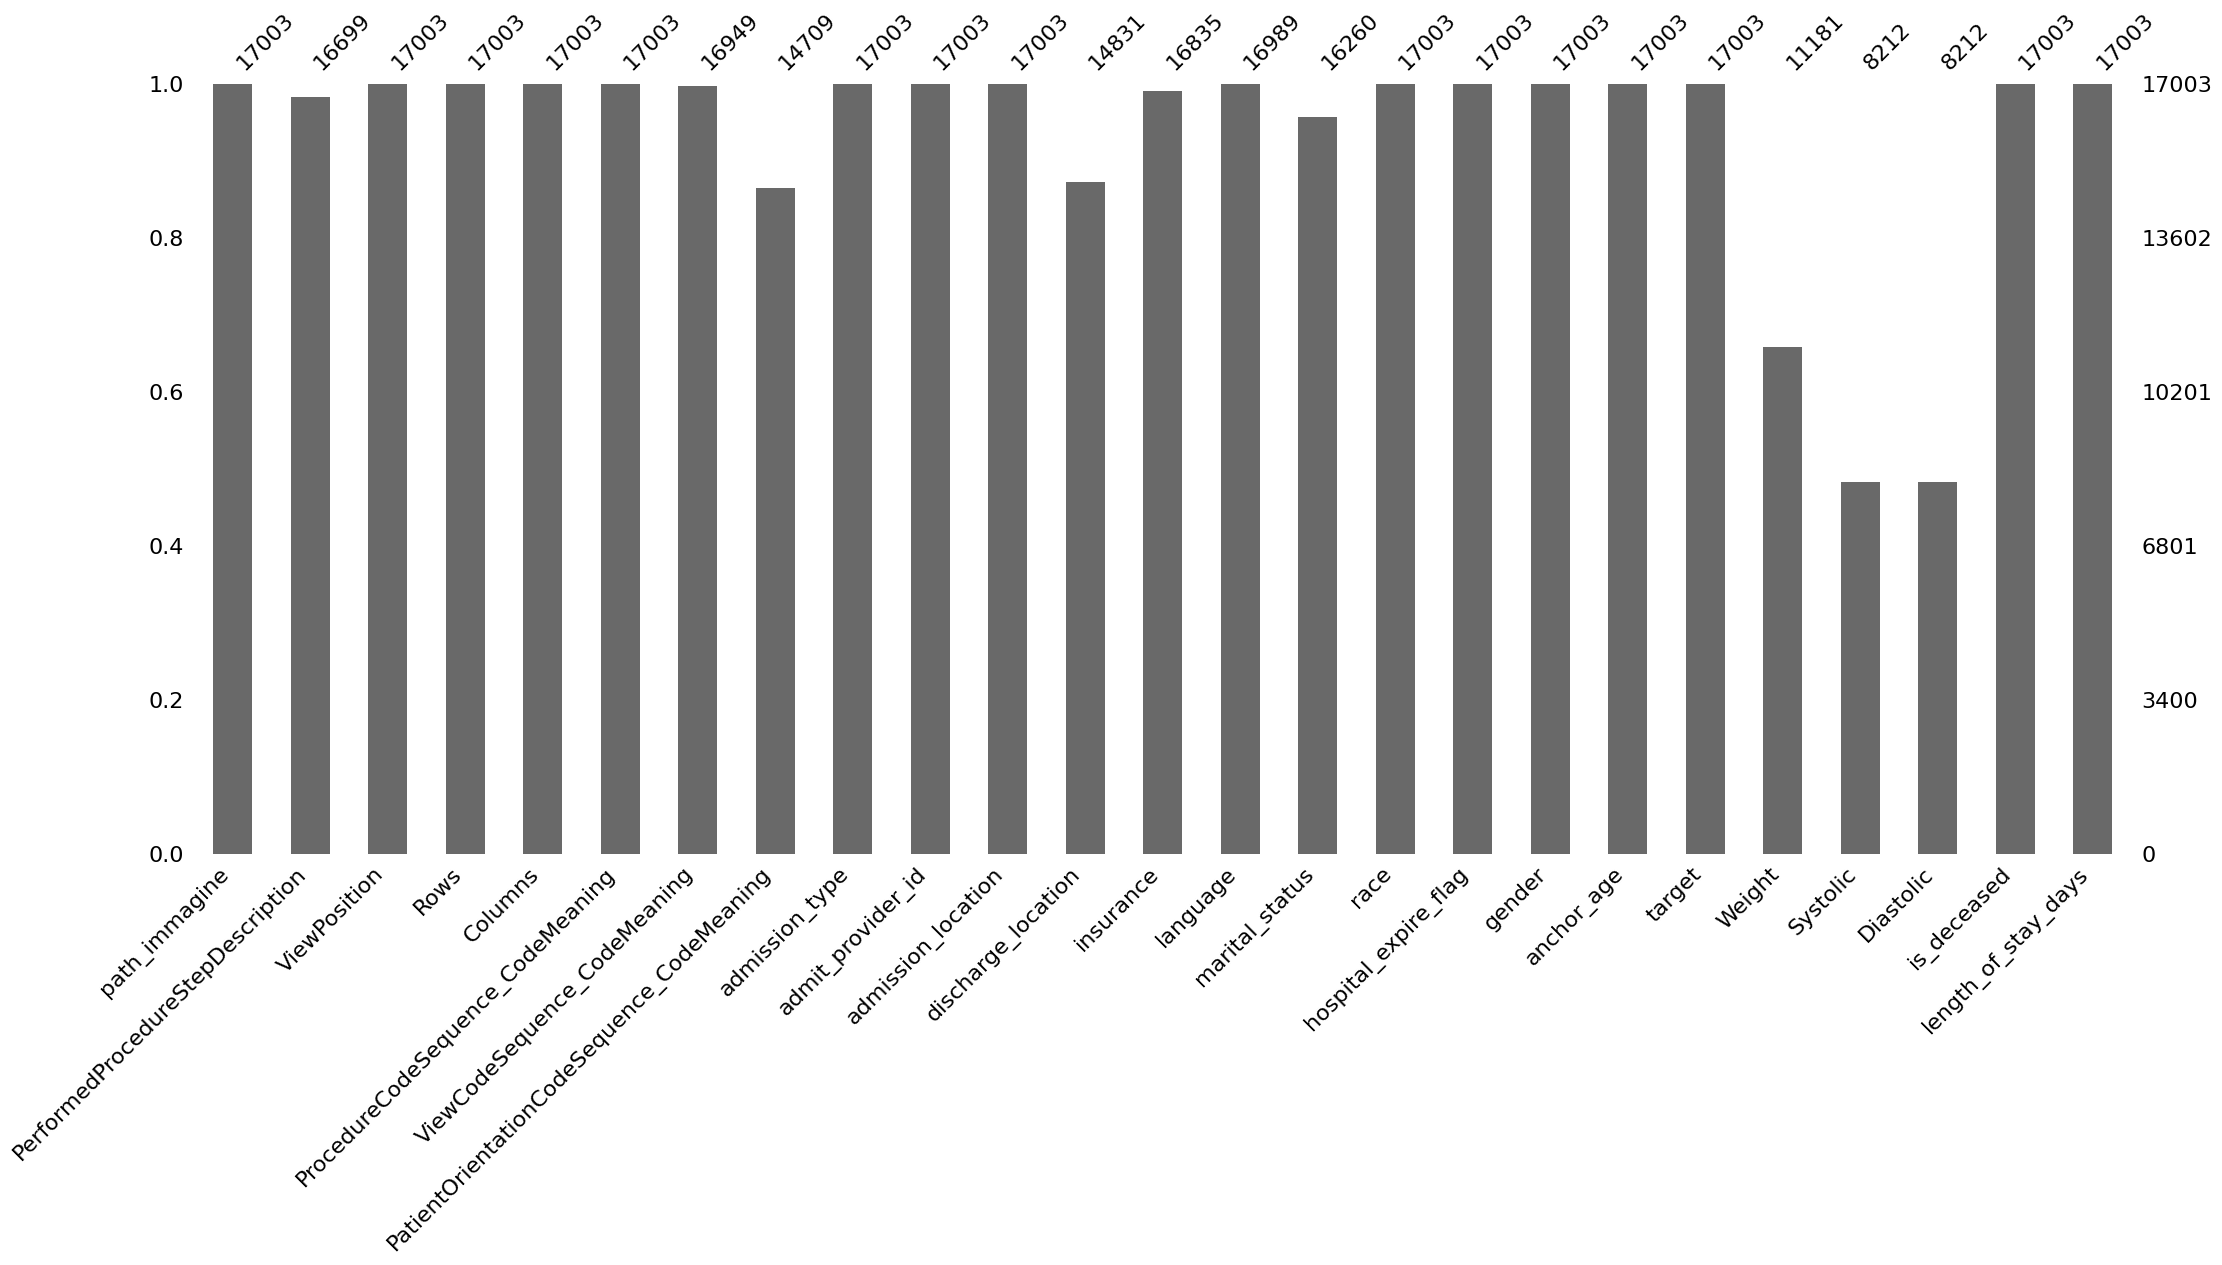

In [112]:
msno.bar(dataset_finale)

<function matplotlib.pyplot.show(close=None, block=None)>

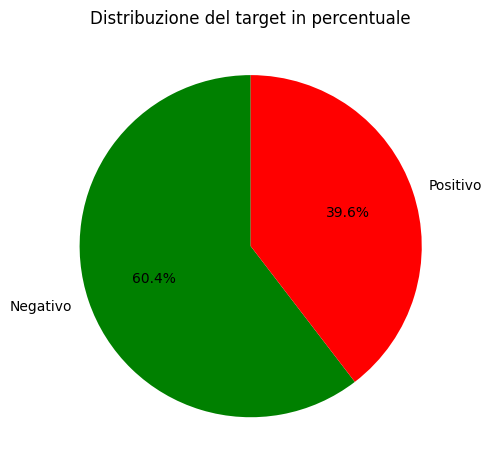

In [113]:
valori = dataset_finale['target'].value_counts()
plt.pie(valori, labels=['Negativo', 'Positivo'], autopct='%1.1f%%', colors=['green', 'red'] ,startangle=90)
plt.title("Distribuzione del target in percentuale")
plt.tight_layout()
plt.show